# 📊 Prompt Testing Experiment Analysis

This notebook analyzes the prompt variants' performance, latency, and costs based on real experiment records logged to the SQLite database.

In [7]:
import os
import sys

# Add workspace root to Python path so we can import our database layer
sys.path.append(os.path.abspath('..'))

from src.core.database import get_results

# Load experiment runs from SQLite
df = get_results()
print(f"Successfully loaded {len(df)} experiment runs from the database.")
df.head()

Successfully loaded 189 experiment runs from the database.


,id,run_id,timestamp,prompt_template,test_inputs_json,variant_name,model,temperature,system_prompt,max_tokens,...,stop_reason,truncated,response,error,accuracy_score,clarity_score,prompt_hash,latency_ms,cost_usd,tags
0,1,run_20260603_133534_5cf028,2026-06-03 13:35:34,Explain the concept of {concept} to a {target_...,"{""concept"": ""Quantum Entanglement"", ""target_au...",Haiku-Concise,claude-haiku-4-5-20251001,0.2,You are a concise assistant. Provide explanati...,1000,...,end_turn,0,# Quantum Entanglement Explained Simply\n\nIma...,,None,None,NaN,NaN,NaN,NaN
1,2,run_20260603_133534_5cf028,2026-06-03 13:35:34,Explain the concept of {concept} to a {target_...,"{""concept"": ""Quantum Entanglement"", ""target_au...",Haiku-PlainProse,claude-haiku-4-5-20251001,0.2,"Respond in plain prose only. No markdown, no h...",200,...,end_turn,0,Imagine you have two magic coins that are best...,,None,None,NaN,NaN,NaN,NaN
2,3,run_20260603_133534_5cf028,2026-06-03 13:35:34,Explain the concept of {concept} to a {target_...,"{""concept"": ""Quantum Entanglement"", ""target_au...",Haiku-Factual,claude-haiku-4-5-20251001,0.0,"You are a precise, academic scientist. Explain...",1000,...,end_turn,0,# Quantum Entanglement Explained Simply\n\nIma...,,None,None,NaN,NaN,NaN,NaN
3,4,run_20260603_133534_5cf028,2026-06-03 13:35:34,Explain the concept of {concept} to a {target_...,"{""concept"": ""Quantum Entanglement"", ""target_au...",Sonnet-Creative,claude-sonnet-4-6,0.7,You are an imaginative storyteller. Explain co...,4000,...,end_turn,0,# The Magic Friendship Bracelet ✨\n\nImagine y...,,None,None,NaN,NaN,NaN,NaN
4,5,run_20260603_133534_5cf028,2026-06-03 13:35:34,Explain the concept of {concept} to a {target_...,"{""concept"": ""Quantum Entanglement"", ""target_au...",Sonnet-Factual,claude-sonnet-4-6,0.0,"You are a precise, academic scientist. Explain...",4000,...,end_turn,0,# Quantum Entanglement for a 10-Year-Old\n\nI'...,,None,None,NaN,NaN,NaN,NaN


In [8]:
# Aggregate metrics by prompt variant
df['cost_per_1k_output'] = (df['cost_usd'] / df['output_tokens']) * 1000
summary = df.groupby('variant_name').agg(
    runs=('id', 'count'),
    avg_latency_ms=('latency_ms', 'mean'),
    avg_input_tokens=('input_tokens', 'mean'),
    avg_output_tokens=('output_tokens', 'mean'),
    total_cost_usd=('cost_usd', 'sum'),
    avg_cost_per_1k_output=('cost_per_1k_output', 'mean')
).reset_index()

print("Variant Performance Summary Comparison:")
summary

Variant Performance Summary Comparison:


,variant_name,runs,avg_latency_ms,avg_input_tokens,avg_output_tokens,total_cost_usd,avg_cost_per_1k_output
0,Haiku-Concise,21,2031.000000,40.000000,144.190476,0.001872,0.004218
1,Haiku-Factual,21,4012.000000,38.000000,361.857143,0.004495,0.004085
2,Haiku-PlainProse,21,1831.000000,44.000000,116.619048,0.001526,0.004299
3,Sonnet-Creative,105,13291.333333,42.419048,472.038095,0.115440,0.015297
4,Sonnet-Factual,21,12494.333333,37.285714,565.714286,0.027051,0.015275


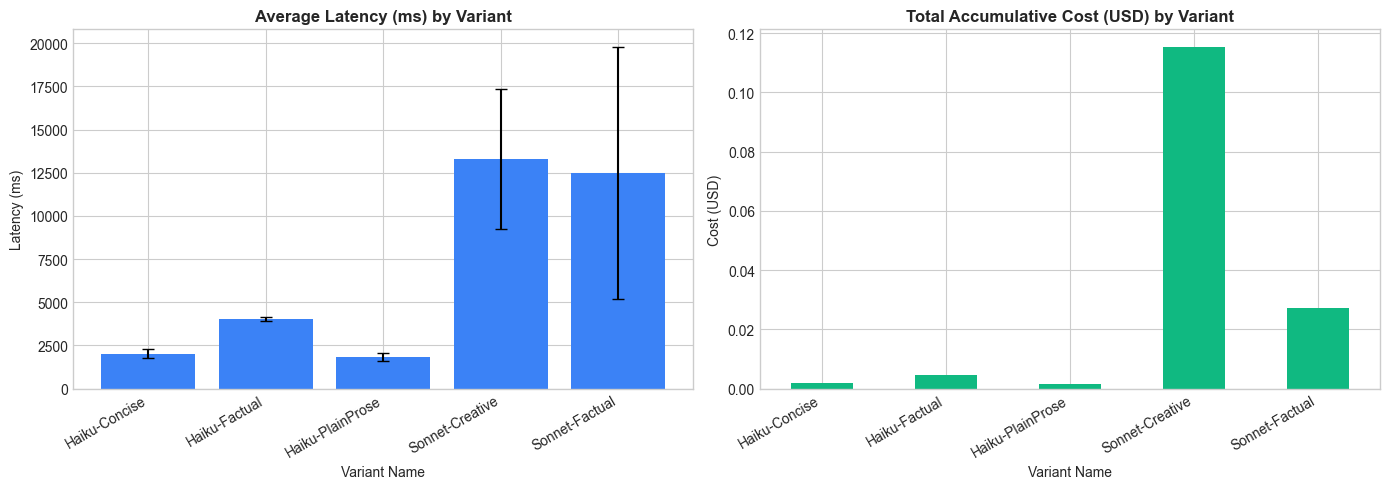

In [9]:
import matplotlib.pyplot as plt

# Configure matplotlib styles
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot average latency per variant with standard deviation error bars
latency_stats = df.groupby('variant_name')['latency_ms'].agg(['mean', 'std']).fillna(0)
axes[0].bar(latency_stats.index, latency_stats['mean'],
            yerr=latency_stats['std'], capsize=4, color='#3b82f6')
axes[0].set_title('Average Latency (ms) by Variant', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_xlabel('Variant Name')
axes[0].set_xticks(range(len(latency_stats)))
axes[0].set_xticklabels(latency_stats.index, rotation=30, ha='right')

# 2. Plot total cost per variant
summary.plot(x='variant_name', y='total_cost_usd', kind='bar', ax=axes[1], color='#10b981', legend=False)
axes[1].set_title('Total Accumulative Cost (USD) by Variant', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cost (USD)')
axes[1].set_xlabel('Variant Name')
axes[1].set_xticklabels(summary['variant_name'], rotation=30, ha='right')

plt.tight_layout()
plt.show()